## Assignment 2: $k$ Nearest Neighbor

### Do any four.

I did 1-3, 6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1.1 Regression is with numeric response variable whereas classification is with categorical response variables (y).

1.2 A confusion table/matrix basically measure the accuracy of the model. It cross-tabulates the true labels with the predicted ones and see if they're similar or not. It helps us understand if the model we fit was good or bad with its predictions and if they align with the actual data.

1.3 Accuracy is what proportion of the scenarios we predicted are correct. It might not be entirely sufficient to evaluate a classifer's predictive performance because we don't want it to regurgitate what it just rememebers that it doesn't actually give us any meaningful insights (overfitting ass) . 

1.4 It quantifies how far it is from the actual data points. It just gives the standard deviation of the model and how far the prediction is from the actual points in the data.

1.5 Overfitting is when you pick a lot of points that it is overly sensitive to everything. It just regurgitates everything it has. Underfitting is when we have a model that it generalizes the population too much and it matchest to the population proportion. 

1.6 This is because it gives us an actual measurable comparison between the predictions and actual data when we test our model. It helps us understand how close our predictions are to the data to prevent overfitting if they are too close to the data and prevent generalizations of underfitting.

1.7 

Report a class label as a prediction: Makes it easier to focus on one prediction but can be biased against the other class labels that can be skewed to whatever is being predicted and does not account for imbalances. It's very limited in what it can predict by only focusing on one label, but it's pretty clear in what it is predicting.

Probability distribution over class labels: The pros consist of being able to account for different class labels, but can make the model too complicated and end up overfitting of the model.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [2]:
# 2.1 Load and EDA
dfLM = pd.read_csv('data/land_mines.csv', encoding='latin1')
dfLM.head()


FileNotFoundError: [Errno 2] No such file or directory: 'data/land_mines.csv'

<Axes: xlabel='height', ylabel='voltage'>

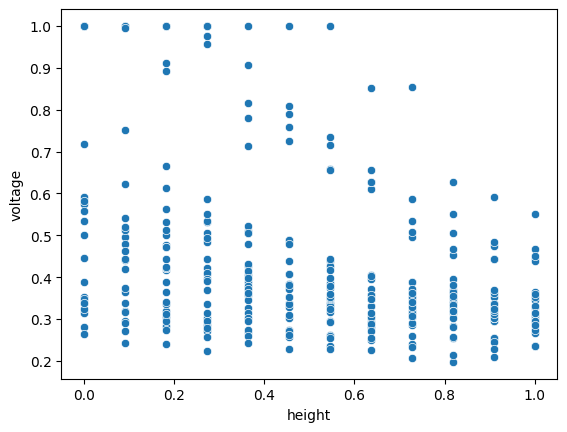

In [3]:
sns.scatterplot(x='height', y='voltage', data=dfLM)

In [4]:
dfLM.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


<Axes: xlabel='soil', ylabel='voltage'>

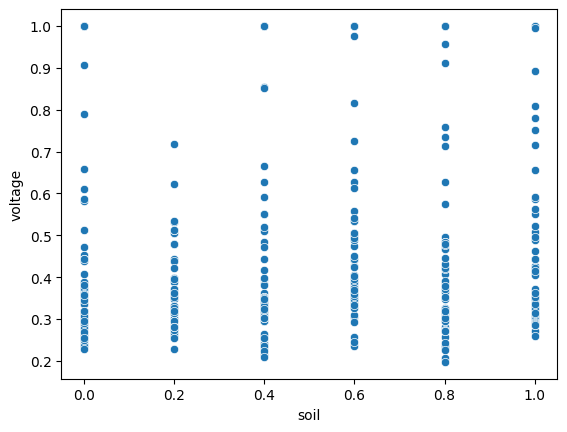

In [5]:
sns.scatterplot(x='soil', y='voltage', data=dfLM)

<Axes: xlabel='mine_type', ylabel='voltage'>

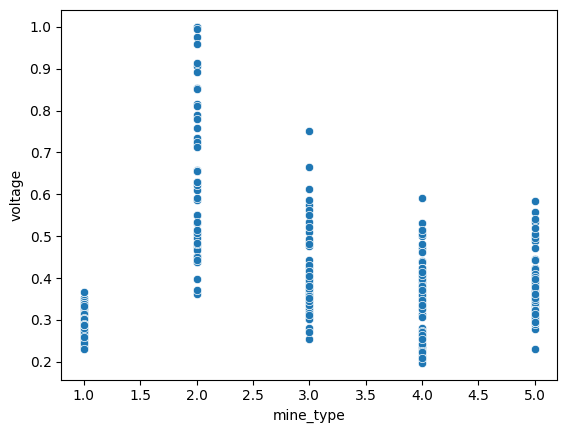

In [6]:
sns.scatterplot(x='mine_type', y='voltage', data=dfLM)

In [13]:
# 2.2 Train/Test Split

def MinMaxScaler(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

feature_cols = dfLM.columns.drop('mine_type')
dfLM[feature_cols] = dfLM[feature_cols].apply(MinMaxScaler)

X = dfLM.drop('mine_type', axis=1)
y = dfLM['mine_type']
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [18]:
# 2.3-4 k-NN Classifier and confusion table
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_hat = knn.predict(X_test)
pd.crosstab(y_test,y_hat)

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)
# I chose this k because as I increased k, it became less accurate and
# decreasing it from k=3 was also not as accurate so this seemed like the best option based on the
# confusion matrix. I also just chose smaller values of k because the dataset is small
# and doesn't have that many features so I didn't want to overcomplicate the model.

array([[11,  0,  1,  0,  1],
       [ 0, 10,  1,  3,  0],
       [ 1,  0,  6,  5,  2],
       [ 4,  1,  7,  3,  1],
       [ 4,  0,  3,  2,  2]])

2.5 The model should be used primarily in situations where it demonstrates strong predictive accuracy, while predictions for mine types with higher misclassification rates should be treated cautiously. Use the model as something that helps human decision making rather than something that is absolutely correct.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [9]:
# 3.1
dfCar = pd.read_csv('data/USA_cars_datasets.csv', encoding='latin1')
dfCar.drop(dfCar.columns.difference(["price", "year", "mileage"]), axis=1, inplace=True)
dfCar.head()

,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [10]:
dfCar.isna().sum() # guess not?

price      0
year       0
mileage    0
dtype: int64

In [ ]:
#3.2
def MinMaxScaler(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

dfCar[["year", "mileage"]] = dfCar[["year", "mileage"]].apply(MinMaxScaler)

In [ ]:
# 3.3
XCar = dfCar.drop('price', axis=1)
yCar = dfCar['price']

X_train, X_test, y_train, y_test = train_test_split(XCar, yCar, test_size=0.2, random_state=100)

In [25]:
# 3.4
modelCar = KNeighborsClassifier(n_neighbors=3)
modelCar.fit(X_train, y_train)
y_hat = modelCar.predict(X_test)
mean_squared_error(y_test, y_hat)

187835221.878

<Axes: xlabel='price'>

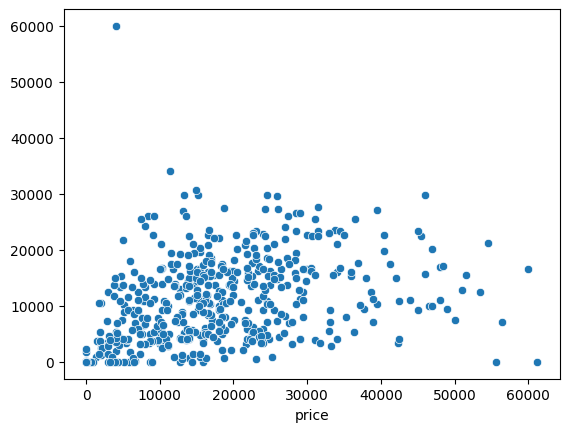

In [24]:
sns.scatterplot(x=y_test, y=y_hat)

In [26]:
modelCar = KNeighborsClassifier(n_neighbors=10)
modelCar.fit(X_train, y_train)
y_hat = modelCar.predict(X_test)
mean_squared_error(y_test, y_hat)

220319626.998

<Axes: xlabel='price'>

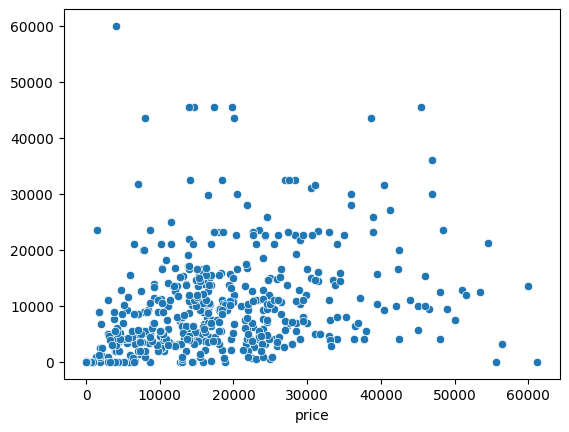

In [27]:
sns.scatterplot(x=y_test, y=y_hat)

In [28]:
modelCar = KNeighborsClassifier(n_neighbors=25)
modelCar.fit(X_train, y_train)
y_hat = modelCar.predict(X_test)
mean_squared_error(y_test, y_hat)

178179831.562

<Axes: xlabel='price'>

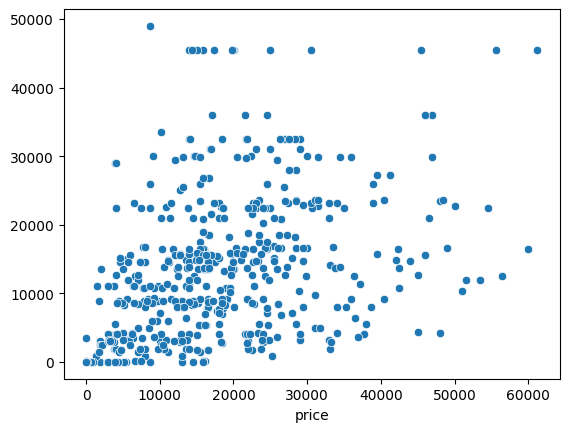

In [29]:
sns.scatterplot(x=y_test, y=y_hat)

In [30]:
modelCar = KNeighborsClassifier(n_neighbors=50)
modelCar.fit(X_train, y_train)
y_hat = modelCar.predict(X_test)
mean_squared_error(y_test, y_hat)

161195261.262

<Axes: xlabel='price'>

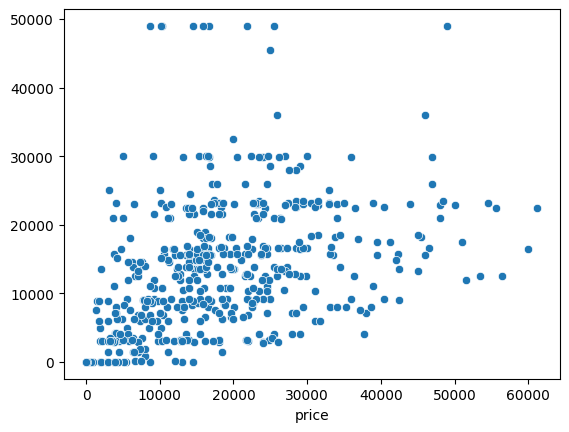

In [31]:
sns.scatterplot(x=y_test, y=y_hat)

In [32]:
modelCar = KNeighborsClassifier(n_neighbors=100)
modelCar.fit(X_train, y_train)
y_hat = modelCar.predict(X_test)
mean_squared_error(y_test, y_hat)

171140720.052

<Axes: xlabel='price'>

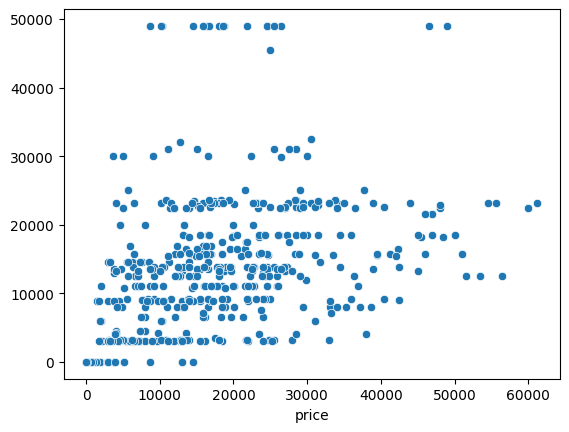

In [33]:
sns.scatterplot(x=y_test, y=y_hat)

In [34]:
modelCar = KNeighborsClassifier(n_neighbors=300)
modelCar.fit(X_train, y_train)
y_hat = modelCar.predict(X_test)
mean_squared_error(y_test, y_hat)

168384327.852

<Axes: xlabel='price'>

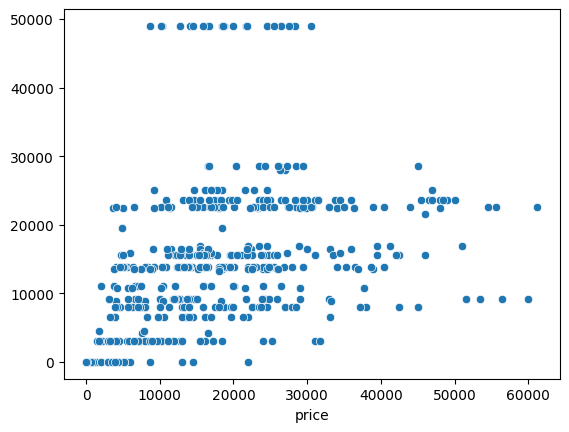

In [35]:
sns.scatterplot(x=y_test, y=y_hat)

As you increase k, the mean squared error decreases. The Graph also seems to be less spread out and there's random points that are at the top.

3.5 Optimal k for this data is 50

3.6 
As k increased, it included more points and tended to underfit, smoothing out the predictions too much. As k decreased, it used fewer points and tended to overfit, following the noise in the data more closely.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [43]:
# 6.1
dfAir= pd.read_csv('data/airbnb_hw.csv', encoding='latin1')
dfAir = dfAir.loc[:,["Review Scores Rating","Price", "Beds"]]
dfAir.head()

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0


In [46]:
# 6.2
dfAirNull = dfAir.loc[dfAir["Review Scores Rating"].isnull()]


In [47]:
# 6.3
dfAir = dfAir.dropna(axis = 0, how = 'any')

In [ ]:
# 6.4
dfAir["Price"] = (dfAir["Price"].astype(str)
                  .str.replace(r"[$,]", "", regex=True))
dfAir["Price"] = pd.to_numeric(dfAir["Price"], errors="coerce")

dfAir["Beds"] = pd.to_numeric(dfAir["Beds"], errors="coerce")

def MinMaxScaler(x):
    u = (x - min(x)) / (max(x) - min(x))
    return u

dfAir[["Price", "Beds"]] = dfAir[["Price", "Beds"]].apply(MinMaxScaler)

X = dfAir[["Price", "Beds"]]
y = dfAir["Review Scores Rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

from sklearn.neighbors import KNeighborsRegressor
modelAir = KNeighborsRegressor(n_neighbors=72)
modelAir.fit(X_train, y_train)

y_hat = modelAir.predict(X_test)

from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_hat)

# I chose k=72 because it had the lowest mean squared error. 
#  tried a lot of different values of k and this one seemed to be the best based on the mean squared error. 

76.93270655914789

In [75]:
# 6.5 
for col in ["Price", "Beds"]:
    dfAir[col] = pd.to_numeric(dfAir[col], errors="coerce")
    dfAirNull[col] = pd.to_numeric(dfAirNull[col], errors="coerce")

dfAir = dfAir.dropna(subset=["Price", "Beds", "Review Scores Rating"]).copy()
dfAirNull = dfAirNull.dropna(subset=["Price", "Beds"]).copy()

X = dfAir[["Price", "Beds"]]
y = dfAir["Review Scores Rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

modelAir.fit(X_train, y_train)

X_missing = dfAirNull[["Price", "Beds"]]
predicted_ratings = modelAir.predict(X_missing)

dfAirNull["Predicted Review Score"] = predicted_ratings

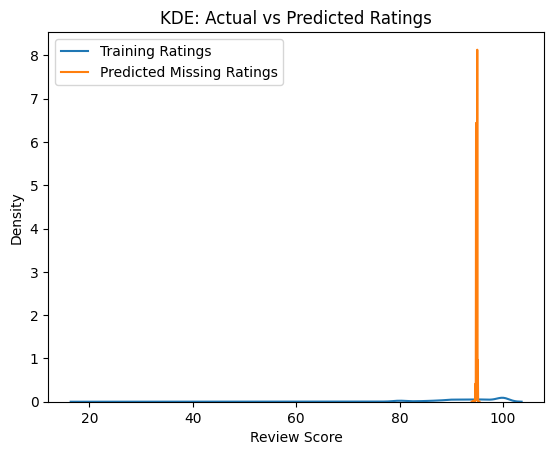

In [78]:
# 6.6

sns.kdeplot(dfAir["Review Scores Rating"], label="Training Ratings")
sns.kdeplot(dfAirNull["Predicted Review Score"], label="Predicted Missing Ratings")

plt.legend()
plt.xlabel("Review Score")
plt.title("KDE: Actual vs Predicted Ratings")
plt.show()

Do they look similar or not? Describe what you see.

They don't look similar. Predicted missing ratings seems to be grouped in one area whereas the training ratings are more spread out across review score.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)